In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
RESULT_ROOT = Path("DeepGCNRT")
RUN_NAME = None

run_dirs = sorted([path for path in RESULT_ROOT.iterdir() if path.is_dir()])
RUN_PATH = RESULT_ROOT / RUN_NAME if RUN_NAME is not None else run_dirs[-1]
RUN_PATH

PosixPath('DeepGCNRT/20260324_103037_097_e9b75031')

In [3]:
def load_run(run_path):
    run_path = Path(run_path)
    log_df = pd.read_csv(run_path / "log.csv")
    pred_df = pd.read_csv(run_path / "test_predictions.csv")
    return log_df, pred_df


def plot_run(run_path):
    log_df, pred_df = load_run(run_path)
    best_idx = log_df["valid_mae"].idxmin()
    best_epoch = int(log_df.loc[best_idx, "epoch"])
    test_mae = (pred_df["target"] - pred_df["prediction"]).abs().mean()

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    epochs = log_df["epoch"]

    axes[0, 0].plot(epochs, log_df["train_loss"], label="train")
    axes[0, 0].plot(epochs, log_df["valid_loss"], label="valid")
    axes[0, 0].plot(epochs, log_df["test_loss"], label="test")
    axes[0, 0].axvline(best_epoch, color="black", linestyle="--", alpha=0.5)
    axes[0, 0].set_title("Loss Curves")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    axes[0, 1].plot(epochs, log_df["train_mae"], label="train", color="tab:blue")
    axes[0, 1].plot(epochs, log_df["valid_mae"], label="valid", color="tab:orange")
    axes[0, 1].plot(epochs, log_df["test_mae"], label="test", color="tab:green")
    axes[0, 1].axvline(best_epoch, color="black", linestyle="--", alpha=0.5)
    axes[0, 1].set_title("MAE Curves")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("MAE")
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    valid_ax = axes[1, 0]
    valid_ax.plot(epochs, log_df["valid_loss"], color="tab:red", label="valid_loss")
    valid_ax.set_title("Valid Curves")
    valid_ax.set_xlabel("Epoch")
    valid_ax.set_ylabel("Valid Loss", color="tab:red")
    valid_ax.tick_params(axis="y", labelcolor="tab:red")
    valid_ax.grid(True, alpha=0.3)
    valid_ax.axvline(best_epoch, color="black", linestyle="--", alpha=0.5)

    valid_mae_ax = valid_ax.twinx()
    valid_mae_ax.plot(
        epochs, log_df["valid_mae"], color="tab:purple", label="valid_mae"
    )
    valid_mae_ax.set_ylabel("Valid MAE", color="tab:purple")
    valid_mae_ax.tick_params(axis="y", labelcolor="tab:purple")

    axes[1, 1].scatter(pred_df["target"], pred_df["prediction"], alpha=0.65, s=18)
    xy_min = min(pred_df["target"].min(), pred_df["prediction"].min())
    xy_max = max(pred_df["target"].max(), pred_df["prediction"].max())
    axes[1, 1].plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--", color="black")
    axes[1, 1].set_title(f"Test Prediction Scatter | MAE={test_mae:.3f}")
    axes[1, 1].set_xlabel("Target")
    axes[1, 1].set_ylabel("Prediction")
    axes[1, 1].grid(True, alpha=0.3)

    fig.suptitle(run_path.name, fontsize=14)
    fig.tight_layout()
    return log_df, pred_df

epoch         176.000000
valid_mae      27.134859
test_mae       26.653452
valid_loss     26.642175
test_loss      26.160402
Name: 175, dtype: float64

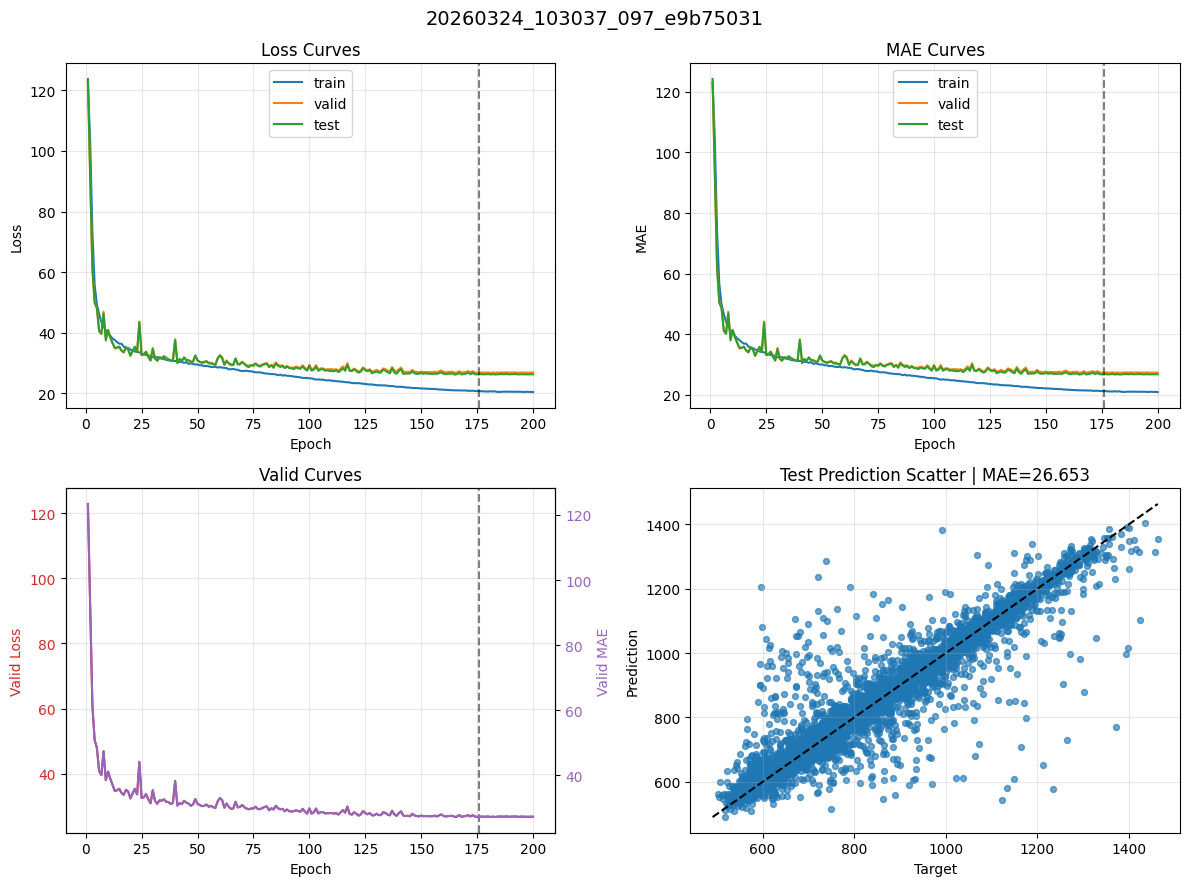

In [4]:
log_df, pred_df = plot_run(RUN_PATH)
log_df.loc[
    log_df["valid_mae"].idxmin(),
    ["epoch", "valid_mae", "test_mae", "valid_loss", "test_loss"],
]